# Background estimation

## 1. Load Data

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Filter**: m600-band
- **Pattern**: Files ending with `*100.fits`


In [1]:
from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'T00528'
dbrowser.filter = 'm600'
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:01<00:00, 83.02it/s]


You can also maks target_imglist from `List of path`

In [2]:
import glob
from ezphot.imageobjects import ScienceImage

target_pathlist = glob.glob('/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/*/m600/*100.fits')
target_imglist = [ScienceImage(path) for path in target_pathlist]

<br><br>
<br><br>

## 2. Background Estimation

Background estimation is crucial for accurate photometry and image analysis.

- **Estimate background** using the SEP (Source Extractor Python) algorithm
- **Apply source masking** to improve background estimation

> **Science Note**: Background estimation removes sky brightness and instrumental effects, revealing the true astronomical sources in your images.
<br><br>

### 2.1. Basic Background Estimation

In [3]:
target_img = target_imglist[0]

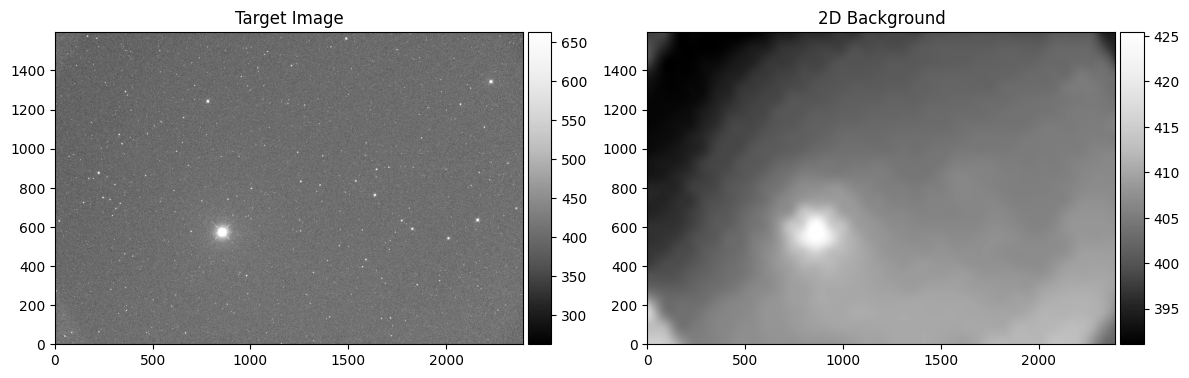

Cleared data and header from memory.


In [4]:
# Calculate the background map
target_bkg = target_img.calculate_bkg(
    target_srcmask = None,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 256,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True
)
# Clear the memory
target_bkg.clear(verbose = True)

<br><br>

### 2.2. Advanced Background Estimation

Sometimes the background model may include real sources like saturated stars or extended objects. In such cases, you can apply source masks to improve the background estimation.

> **💡 Pro Tip**: Source masking helps create cleaner background models by excluding bright objects that could bias the background calculation.


#### 2.2.1. Automatic Source Mask Generation 

Masking source... [sigma = 5.0, mask_radius_factor = 2]
2948 non-saturated, 13 saturated sources
2961 sources masked.


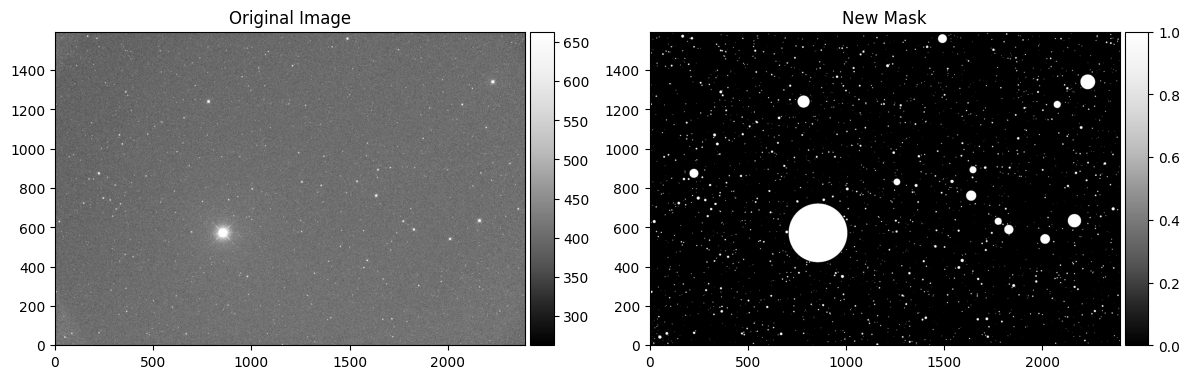

Iteration 1
External mask is loaded.
Masking source... [sigma = 5.0, mask_radius_factor = 2]
119 non-saturated, 0 saturated sources
119 sources masked.


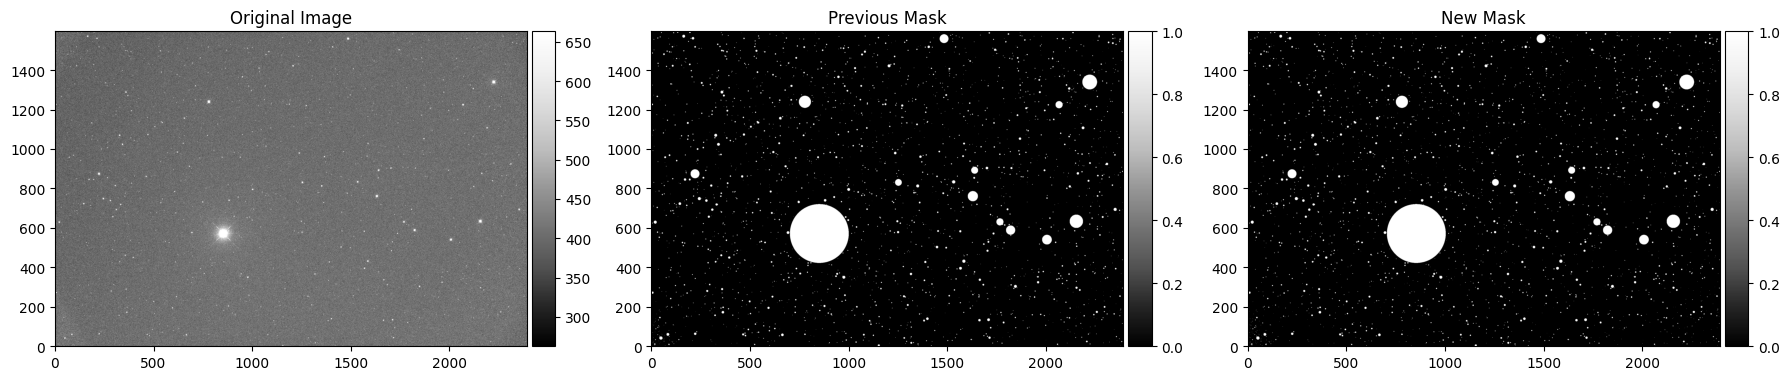

Iteration 2
External mask is loaded.
Masking source... [sigma = 5.0, mask_radius_factor = 2]
No sources detected to mask.


In [5]:
target_srcmask = target_img.calculate_sourcemask(
    target_srcmask = None,
    sigma = 5.0,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)
# You can also iteratively apply source masking to the existing source mask,
for i in range(2):
    print('Iteration', i+1)
    target_srcmask = target_img.calculate_sourcemask(
        target_srcmask = target_srcmask,
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
    )


#### 2.2.2. Manual Mask Generation

Added circular mask at (325.37, -77.39) with radius 300arcsec


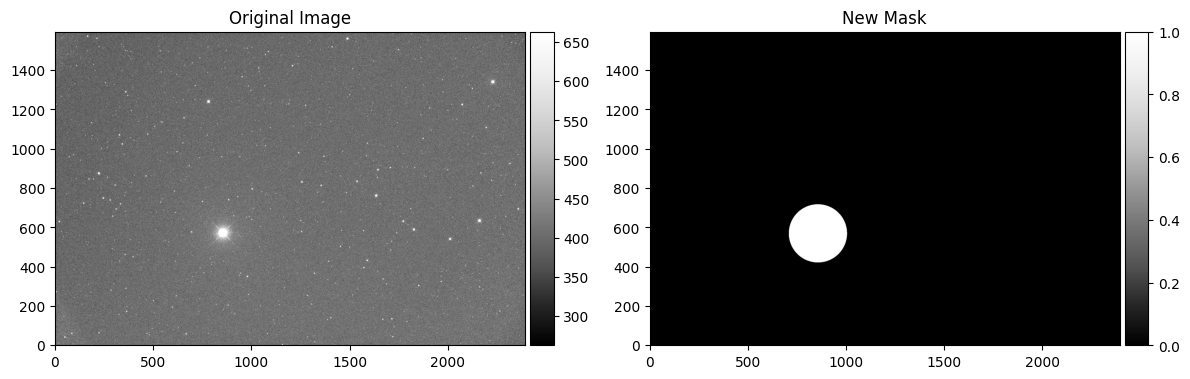

In [6]:
# If you wish to add manual source mask to reject the extended sources when background modeling,
target_srcmask = target_img.calculate_circularmask(
    target_srcmask = None,
    x_position = 325.37,
    y_position = -77.393,
    radius_arcsec = 300,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False)

External mask is loaded.
Added circular mask at (325.07, -77.09) with radius 100arcsec


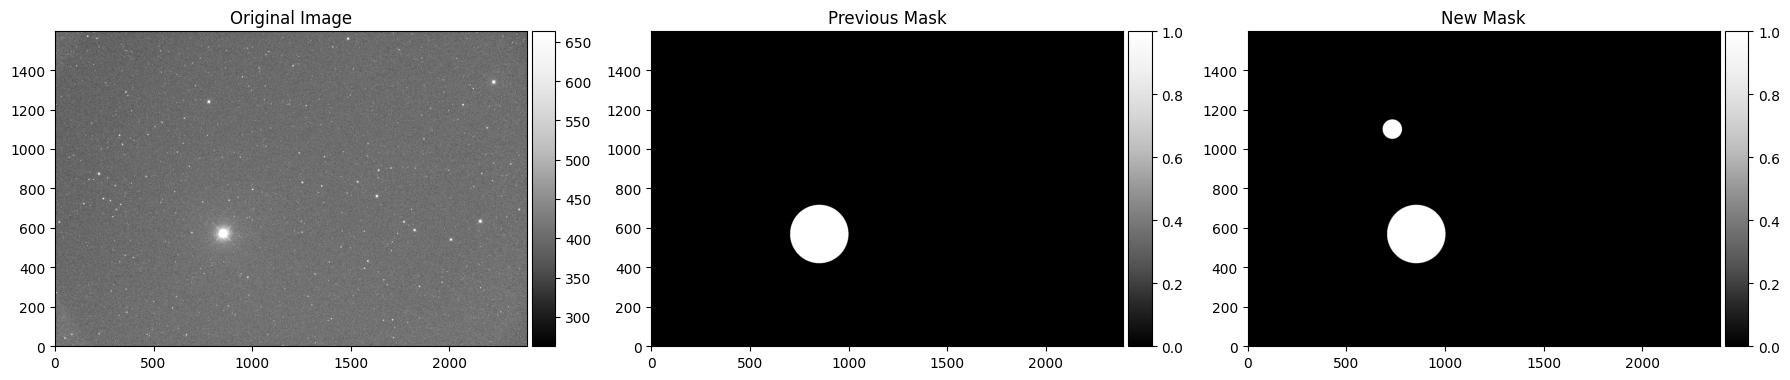

In [8]:
# Or If you wish to add manual source mask to the existing source mask,
target_srcmask = target_img.calculate_circularmask(
    target_srcmask = target_srcmask,
    x_position = 325.07,
    y_position = -77.093,
    radius_arcsec = 100,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False)

#### 2.2.3. Re-generation of Background Map with Source Mask


External mask is loaded.


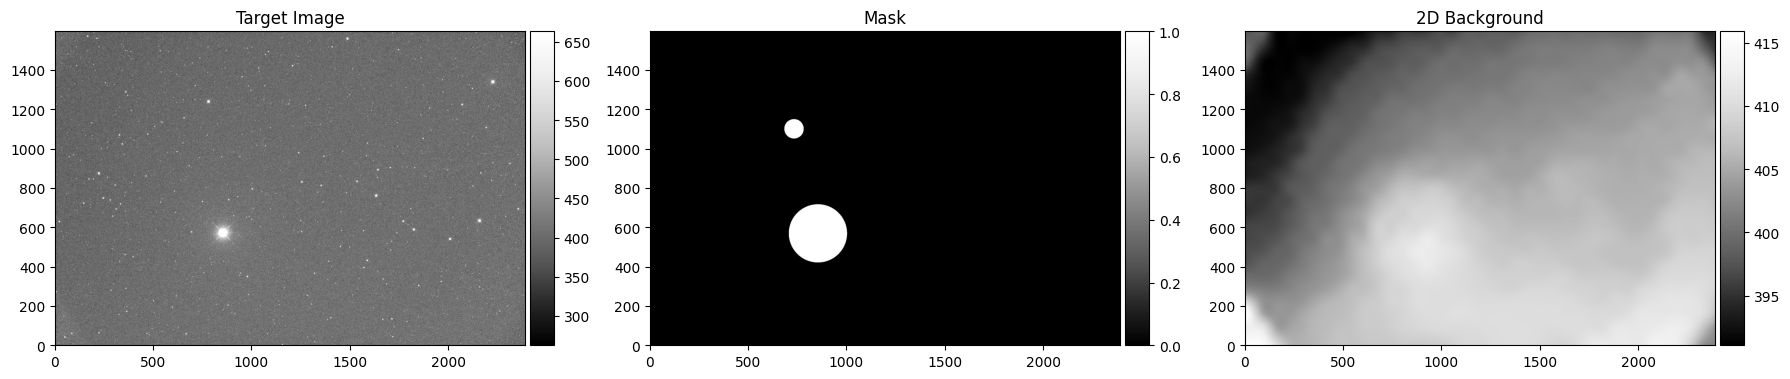

In [9]:
target_bkg_with_srcmask = target_img.calculate_bkg(
    target_srcmask = target_srcmask,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 256,
    filter_size = 3,
)

In [10]:
# Run for all target_imglist with multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

def calculate_bkg(target_img):    
    target_srcmask = target_img.calculate_sourcemask(   
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_img.calculate_bkg(
        target_srcmask = target_srcmask,
        target_ivpmask = None,
        is_2D_bkg = True,
        box_size = 128,
        filter_size = 3,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )    
                
    target_srcmask.clear(verbose = False)
    target_bkg.clear(verbose = False)
    
with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    list(tqdm(pool.imap(calculate_bkg, target_imglist), 
              total=len(target_imglist), 
              desc="Calculating backgrounds"))


Calculating backgrounds: 100%|██████████| 90/90 [05:25<00:00,  3.62s/it]



After calculation of background with save option as "TRUE", you can access to the backgrounds esaily from different options (`DataBrowser`, `ImageSet`)

In [11]:
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'T00528'
dbrowser.filter = 'm600'
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
# From ImageSet
target_bkglist = target_imgset.bkgmap
# From DataBrowser
target_bkglist = dbrowser.search('*.bkgmap', return_type = 'background')

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


Loading bkgmap: 100%|██████████| 90/90 [00:00<00:00, 110.35it/s]


[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*.bkgmap'


Loading Backgrounds: 100%|██████████| 90/90 [00:00<00:00, 598.32it/s]
